<font color='black' size='4' face='Tenor Sans'>

In [98]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error

import os
import warnings
warnings.filterwarnings("ignore")

In [99]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)

In [100]:
df = pd.read_csv('data_A.csv')
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.47,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.00,Good,1023.93,33.47,20 Years and 5 Months,No,100.16,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.99,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.00,Bad,2545.0,33.81,14 Years and 8 Months,Yes,111.42,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.18,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.00,Good,730.64,31.15,23 Years and 10 Months,NM,135.04,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.12,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.00,Standard,932.32,28.41,27 Years and 0 Months,No,180.62,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.61,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.00,Bad,3777.55,28.37,10 Years and 3 Months,Yes,78.95,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


# EDA

## Data Cleaning

### Mismatch Data Types

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [102]:
df['Age'] = df['Age'].fillna('0').str.extract('(\d+)').astype(float).astype(int)
df['Num_of_Loan'] = df['Num_of_Loan'].fillna('0').str.extract('(\d+)').astype(float).astype(int)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna('0').str.extract('(\d+)').astype(float).astype(int)

In [103]:
df['Annual_Income'] = df['Annual_Income'].str.replace(r'[^0-9.]', '', regex=True)
df['Annual_Income'] = df['Annual_Income'].astype(float)

In [104]:
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('_', np.nan)
df['Changed_Credit_Limit'] = pd.to_numeric(df['Changed_Credit_Limit'], errors='coerce')
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(0)

In [105]:
df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(str)
df['Outstanding_Debt'] = df['Outstanding_Debt'].str.replace(r'[^0-9.]', '', regex=True)
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
df['Outstanding_Debt'] = df['Outstanding_Debt'].fillna(0)

In [106]:
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(str)
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].replace('', '0')
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].str.replace(r'[^0-9.]', '')
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(0)

In [107]:
df['Monthly_Balance'] = df['Monthly_Balance'].astype(str)
df['Monthly_Balance'] = df['Monthly_Balance'].str.replace(r'[^0-9.-]+', '')
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(0)

In [108]:
extracted = df['Credit_History_Age'].str.extract(r'(?P<years>\d+)\s*Years\s*and\s*(?P<months>\d+)\s*Months')
extracted = extracted.fillna(0).astype(int)
df['Credit_History_Age_Months'] = (extracted['years'] * 12) + extracted['months']
df.drop(columns=['Credit_History_Age'], inplace=True)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 25000 non-null  int64  
 1   ID                         25000 non-null  object 
 2   Customer_ID                25000 non-null  object 
 3   Month                      25000 non-null  object 
 4   Name                       22440 non-null  object 
 5   Age                        25000 non-null  int64  
 6   SSN                        25000 non-null  object 
 7   Occupation                 25000 non-null  object 
 8   Annual_Income              25000 non-null  float64
 9   Monthly_Inhand_Salary      21417 non-null  float64
 10  Num_Bank_Accounts          25000 non-null  int64  
 11  Num_Credit_Card            25000 non-null  int64  
 12  Interest_Rate              25000 non-null  int64  
 13  Num_of_Loan                25000 non-null  int

### Duplicates

In [110]:
df.duplicated().sum()

np.int64(0)

### Outliers

In [111]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25000.00,12499.50,7217.02,0.00,6249.75,12499.50,18749.25,24999.00
Age,25000.00,114.25,661.82,14.00,25.00,33.00,42.00,8698.00
Annual_Income,25000.00,191805.81,1531877.57,7005.93,19559.45,37813.63,73096.78,24188807.00
Monthly_Inhand_Salary,21417.00,4215.67,3187.62,303.65,1634.72,3111.44,5986.65,15167.18
Num_Bank_Accounts,25000.00,17.24,118.31,-1.00,4.00,6.00,7.00,1798.00
Num_Credit_Card,25000.00,22.14,127.70,0.00,4.00,5.00,7.00,1499.00
Interest_Rate,25000.00,71.21,463.67,1.00,8.00,13.00,20.00,5775.00
Num_of_Loan,25000.00,10.68,60.91,0.00,2.00,3.00,6.00,1482.00
Delay_from_due_date,25000.00,21.19,14.89,-5.00,10.00,18.00,28.00,67.00
Num_of_Delayed_Payment,25000.00,28.31,214.90,0.00,8.00,13.00,18.00,4388.00


In [112]:
num_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [113]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,20945.00,12490.23,7217.87,1.00,6242.00,12484.00,18715.00,24999.00
Age,20945.00,33.35,10.83,14.00,24.00,33.00,42.00,56.00
Annual_Income,20945.00,197020.54,1546546.04,7005.93,19798.93,38138.12,74008.84,24188807.00
Monthly_Inhand_Salary,17933.00,4284.69,3220.96,332.13,1662.46,3147.64,6102.16,15167.18
Num_Bank_Accounts,20945.00,5.28,2.57,0.00,3.00,5.00,7.00,11.00
Num_Credit_Card,20945.00,5.45,2.05,0.00,4.00,5.00,7.00,11.00
Interest_Rate,20945.00,14.17,8.58,1.00,7.00,12.00,20.00,34.00
Num_of_Loan,20945.00,3.46,2.41,0.00,2.00,3.00,5.00,9.00
Delay_from_due_date,20945.00,19.63,12.93,-5.00,10.00,17.00,27.00,55.00
Num_of_Delayed_Payment,20945.00,12.20,6.85,0.00,8.00,12.00,18.00,28.00


### Illogical Values

In [114]:
df = df[df['Age'] < 90]
df = df[df['Num_Credit_Card'] <= 15]
df = df[df['Interest_Rate'] <= 50]
df = df[df['Num_of_Loan'] <= 15]
df = df[(df['Num_Bank_Accounts'] > 0) & (df['Num_Bank_Accounts'] <= 10)]
df = df[(df['Delay_from_due_date'] > 0) & (df['Delay_from_due_date'] <= 60)]
df = df[(df['Changed_Credit_Limit'] > 0) & (df['Changed_Credit_Limit'] <= 30)]
df = df[df['Num_Credit_Inquiries'] <= 15]
df = df[df['Total_EMI_per_month'] <= 200]
df = df[df['Outstanding_Debt'] <= 1500]

In [115]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10426.00,12471.49,7236.72,2.00,6155.75,12477.50,18691.50,24997.00
Age,10426.00,34.89,11.08,14.00,26.00,35.00,44.00,56.00
Annual_Income,10426.00,188904.98,1497677.35,7006.52,21642.16,36233.53,73346.13,23565022.00
Monthly_Inhand_Salary,8872.00,4245.20,3103.09,361.60,1826.39,3047.46,6048.79,15090.08
Num_Bank_Accounts,10426.00,4.76,2.05,1.00,3.00,5.00,6.00,10.00
Num_Credit_Card,10426.00,4.85,1.68,0.00,4.00,5.00,6.00,10.00
Interest_Rate,10426.00,10.58,5.86,1.00,6.00,10.00,15.00,34.00
Num_of_Loan,10426.00,2.28,1.74,0.00,1.00,2.00,3.00,9.00
Delay_from_due_date,10426.00,15.66,9.03,1.00,9.00,14.00,22.00,55.00
Num_of_Delayed_Payment,10426.00,10.77,6.13,0.00,7.00,11.00,16.00,28.00


### Unknown Values

In [116]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [117]:
for col in df.columns:
    print(df[col].value_counts(), "\n")

ID
0x7e21     1
0xdcf5     1
0x14453    1
0x84e0     1
0xc7a3     1
          ..
0x12b78    1
0xdd8f     1
0xfea1     1
0x64ad     1
0xf2b8     1
Name: count, Length: 10426, dtype: int64 

Customer_ID
CUS_0xbd37    6
CUS_0xab3b    6
CUS_0x5840    6
CUS_0x791e    6
CUS_0x43c2    5
             ..
CUS_0x7315    1
CUS_0x21af    1
CUS_0x695e    1
CUS_0x875     1
CUS_0xa801    1
Name: count, Length: 5596, dtype: int64 

Month
March       1364
January     1327
May         1318
February    1316
April       1302
June        1290
July        1263
August      1246
Name: count, dtype: int64 

Name
Jonathan Cableo    9
Daniel Flynnu      8
Herbst-Baylisso    8
Andreat            8
Clarer             8
                  ..
Henryq             1
Jennifer Clarku    1
Wahbau             1
Donny Kwokc        1
Michael Taylorz    1
Name: count, Length: 4872, dtype: int64 

Age
27    321
26    321
28    317
30    317
36    317
23    312
41    309
24    299
22    297
44    295
38    293
25    289
32    286

In [118]:
df = df[df['Payment_Behaviour'] != '!@9#%8']
print(df['Payment_Behaviour'].unique())

['Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'Low_spent_Large_value_payments' 'High_spent_Large_value_payments'
 'High_spent_Medium_value_payments' 'High_spent_Small_value_payments']


In [119]:
df = df[df['Occupation'] != '_______']
print(df['Occupation'].unique())

['Musician' 'Accountant' 'Journalist' 'Writer' 'Doctor' 'Media_Manager'
 'Developer' 'Architect' 'Engineer' 'Teacher' 'Lawyer' 'Manager'
 'Entrepreneur' 'Mechanic' 'Scientist']


In [120]:
df = df[df['Credit_Mix'] != '_']
print(df['Credit_Mix'].unique())

['Standard' 'Good' 'Bad']


### Null Values

In [121]:
print(df.isnull().sum())

ID                              0
Customer_ID                     0
Month                           0
Name                          706
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary        1044
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                 1287
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
Credit_History_Age_Months       0
dtype: int64


In [122]:
df.dropna(inplace=True)
print(df.isnull().sum())

ID                           0
Customer_ID                  0
Month                        0
Name                         0
Age                          0
SSN                          0
Occupation                   0
Annual_Income                0
Monthly_Inhand_Salary        0
Num_Bank_Accounts            0
Num_Credit_Card              0
Interest_Rate                0
Num_of_Loan                  0
Type_of_Loan                 0
Delay_from_due_date          0
Num_of_Delayed_Payment       0
Changed_Credit_Limit         0
Num_Credit_Inquiries         0
Credit_Mix                   0
Outstanding_Debt             0
Credit_Utilization_Ratio     0
Payment_of_Min_Amount        0
Total_EMI_per_month          0
Amount_invested_monthly      0
Payment_Behaviour            0
Monthly_Balance              0
Credit_Score                 0
Credit_History_Age_Months    0
dtype: int64


### Distribution

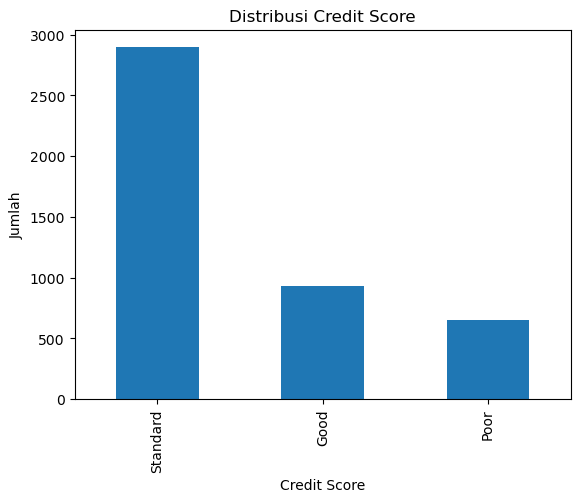

In [123]:
df['Credit_Score'].value_counts().plot(kind='bar')

plt.title('Distribusi Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Jumlah')
plt.show()

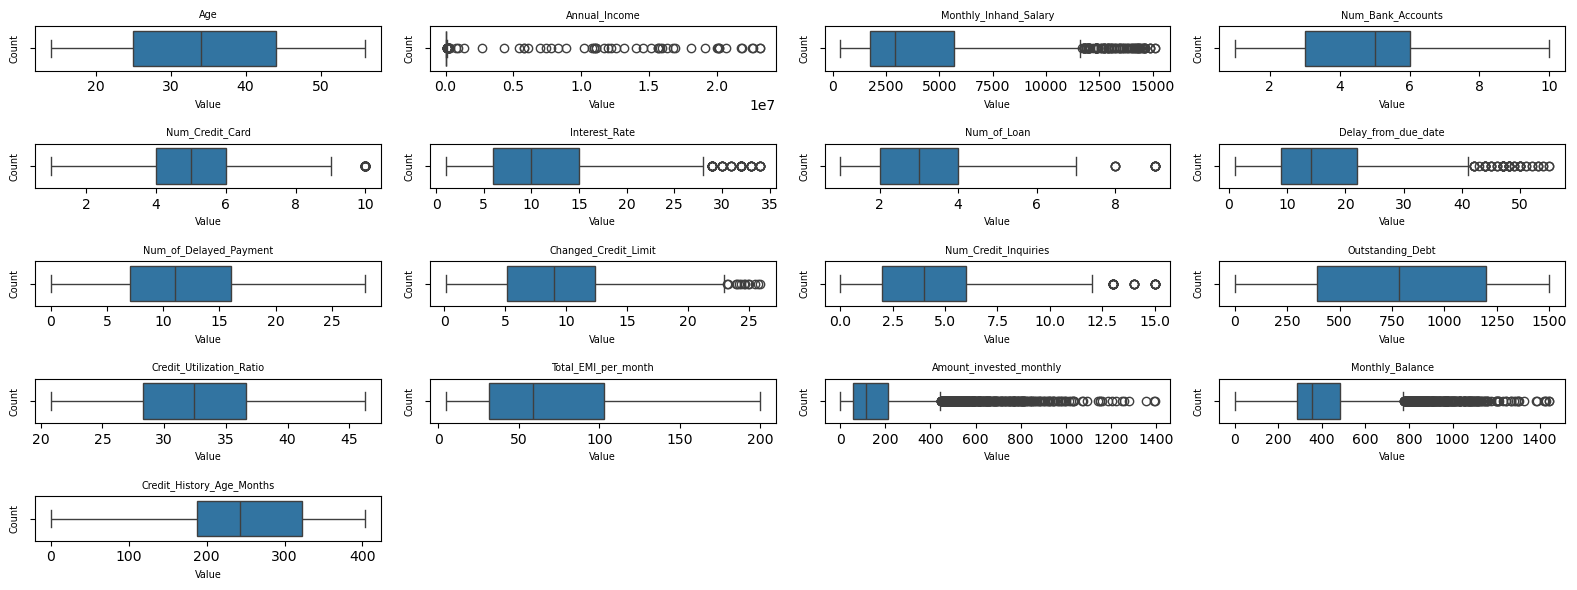

In [124]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

num_columns = 4
num_rows = (len(numeric_columns) + num_columns - 1) // num_columns

fig, axes = plt.subplots(num_rows, num_columns, figsize=(16, 6))

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(column, fontsize=7)  
    axes[i].set_xlabel('Value', fontsize=7)  
    axes[i].set_ylabel('Count', fontsize=7)  

for j in range(len(numeric_columns), num_columns*num_rows):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Correlation Matrix

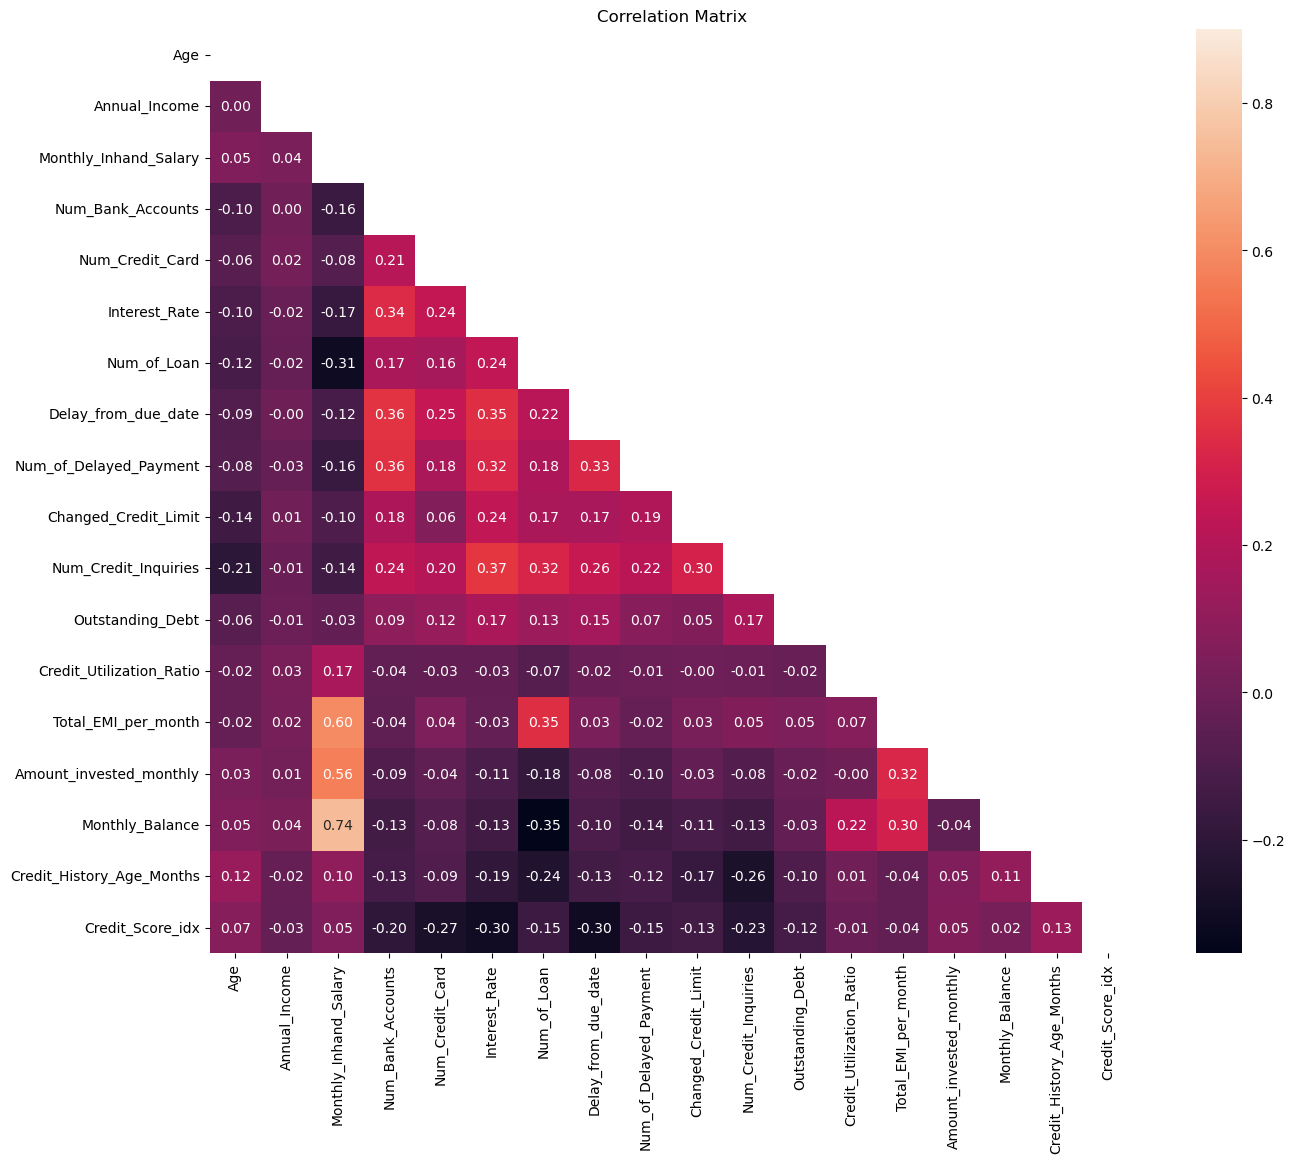

In [125]:
mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score_idx'] = df['Credit_Score'].map(mapping)
num_cols = df.select_dtypes(include=['number']).columns

corr = df.select_dtypes(include=['float64', 'int64']).corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, vmax=0.9, square=True, fmt='.2f', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [126]:
df.drop(columns=['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Credit_Score_idx', 'Type_of_Loan'], inplace=True)
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months
3,29,Musician,142081.48,11771.12,6,6,15,3,29,20,8.21,4.00,Standard,932.32,28.41,No,180.62,423.96,Low_spent_Small_value_payments,862.53,Standard,324
6,18,Accountant,53251.36,4636.61,5,3,20,3,30,0,19.82,7.00,Standard,861.67,26.01,NM,128.21,181.33,Low_spent_Large_value_payments,424.12,Standard,324
12,46,Writer,83823.22,6841.27,3,5,11,1,6,9,10.31,0.00,Good,184.71,37.60,No,41.30,451.55,Low_spent_Medium_value_payments,471.27,Poor,245
13,29,Doctor,18002.67,1430.22,6,3,10,3,27,15,0.94,6.00,Good,698.05,29.98,No,34.03,32.73,High_spent_Large_value_payments,316.26,Good,339
26,39,Writer,34126.19,2619.85,5,7,10,3,8,14,12.51,9.00,Standard,963.43,27.04,Yes,50.65,28.45,High_spent_Large_value_payments,422.89,Standard,151


In [127]:
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Credit_History_Age_Months'],
      dtype='object')

In [128]:
df.shape

(4474, 22)

# Model

## Train-Test Split

In [129]:
ord_cols = ['Credit_Mix', 'Payment_of_Min_Amount']
nom_cols = ['Occupation', 'Payment_Behaviour']
num_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
]

X = df[ord_cols + nom_cols + num_cols]
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
target_encoder = LabelEncoder()
y_train_clean = target_encoder.fit_transform(y_train)
y_test_clean = target_encoder.transform(y_test)

y_train_clean.shape, y_test_clean.shape

((3579,), (895,))

In [131]:
ord_encoder = OrdinalEncoder()
X_train_ord = ord_encoder.fit_transform(X_train[ord_cols])
X_test_ord = ord_encoder.transform(X_test[ord_cols])

In [132]:
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_nom = ohe_encoder.fit_transform(X_train[nom_cols])
X_test_nom = ohe_encoder.transform(X_test[nom_cols])

In [133]:
scaler = RobustScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [134]:
X_train_clean = np.hstack((X_train_ord, X_train_nom, X_train_num))
X_test_clean = np.hstack((X_test_ord, X_test_nom, X_test_num))

X_train_clean.shape, X_test_clean.shape

((3579, 40), (895, 40))

## K-Nearest Neighbors 

In [135]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_clean, y_train_clean)

KNeighborsClassifier(metric='euclidean')

KNN Accuracy: 0.6994413407821229


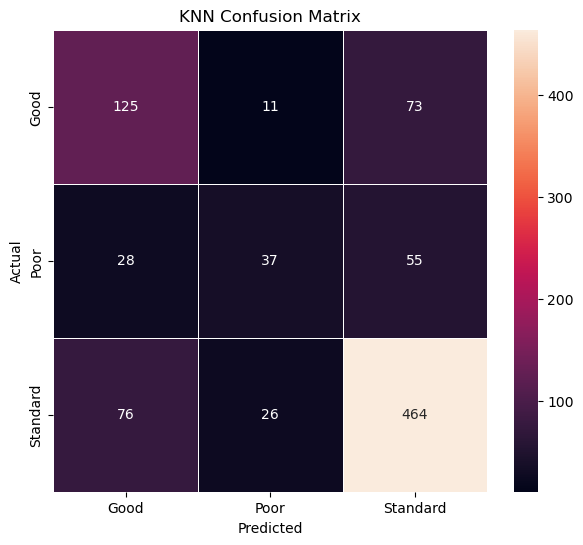


Classification Report
               precision    recall  f1-score   support

        Good       0.55      0.60      0.57       209
        Poor       0.50      0.31      0.38       120
    Standard       0.78      0.82      0.80       566

    accuracy                           0.70       895
   macro avg       0.61      0.58      0.58       895
weighted avg       0.69      0.70      0.69       895



In [136]:
y_pred_knn = knn.predict(X_test_clean)

accuracy = accuracy_score(y_test_clean, y_pred_knn)
print("KNN Accuracy:", accuracy)

matrix = confusion_matrix(y_test_clean, y_pred_knn)
plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix, 
    annot=True, 
    linewidth=0.5, 
    fmt="d",
    xticklabels=target_encoder.classes_, 
    yticklabels=target_encoder.classes_
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('KNN Confusion Matrix')
plt.show()

print('\nClassification Report\n', classification_report(y_test_clean, y_pred_knn, target_names=target_encoder.classes_))

## XGBoost

In [137]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_clean, y_train_clean)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

XGB Accuracy: 0.7575418994413408


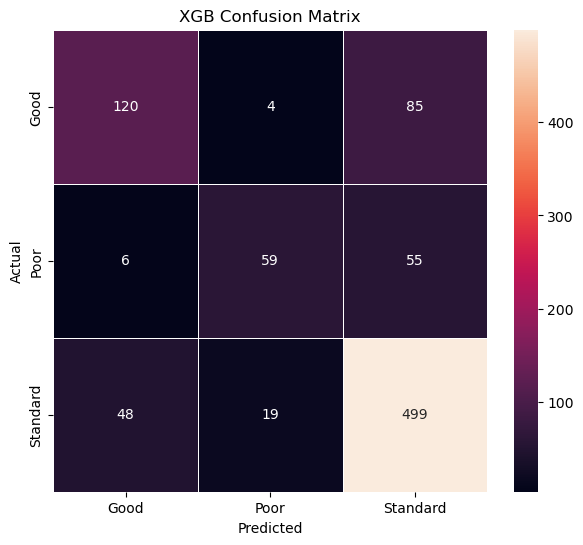


Classification Report
               precision    recall  f1-score   support

        Good       0.69      0.57      0.63       209
        Poor       0.72      0.49      0.58       120
    Standard       0.78      0.88      0.83       566

    accuracy                           0.76       895
   macro avg       0.73      0.65      0.68       895
weighted avg       0.75      0.76      0.75       895



In [138]:
y_pred_xgb = xgb.predict(X_test_clean)

accuracy = accuracy_score(y_test_clean, y_pred_xgb)
print("XGB Accuracy:", accuracy)

matrix = confusion_matrix(y_test_clean, y_pred_xgb)
plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix, 
    annot=True, 
    linewidth=0.5, 
    fmt="d",
    xticklabels=target_encoder.classes_, 
    yticklabels=target_encoder.classes_
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('XGB Confusion Matrix')
plt.show()

print('\nClassification Report\n', classification_report(y_test_clean, y_pred_xgb, target_names=target_encoder.classes_))

## Random Forest

In [139]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_clean, y_train_clean)

RandomForestClassifier(random_state=42)

RFC Accuracy: 0.7653631284916201


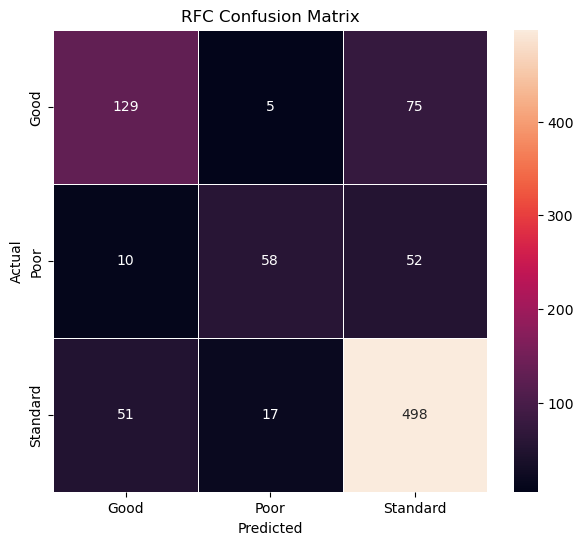


Classification Report
               precision    recall  f1-score   support

        Good       0.68      0.62      0.65       209
        Poor       0.72      0.48      0.58       120
    Standard       0.80      0.88      0.84       566

    accuracy                           0.77       895
   macro avg       0.73      0.66      0.69       895
weighted avg       0.76      0.77      0.76       895



In [140]:
y_pred_rfc = rfc.predict(X_test_clean)

accuracy = accuracy_score(y_test_clean, y_pred_rfc)
print("RFC Accuracy:", accuracy)

matrix = confusion_matrix(y_test_clean, y_pred_rfc)
plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix, 
    annot=True, 
    linewidth=0.5, 
    fmt="d",
    xticklabels=target_encoder.classes_, 
    yticklabels=target_encoder.classes_
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('RFC Confusion Matrix')
plt.show()

print('\nClassification Report\n', classification_report(y_test_clean, y_pred_rfc, target_names=target_encoder.classes_))

## Best Model Analysis

In [141]:
# KNN
knn_acc = accuracy_score(y_test_clean, y_pred_knn)
knn_f1 = f1_score(y_test_clean, y_pred_knn, average='macro')

# XGB
xgb_acc = accuracy_score(y_test_clean, y_pred_xgb)
xgb_f1 = f1_score(y_test_clean, y_pred_xgb, average='macro')

# RFC
rfc_acc = accuracy_score(y_test_clean, y_pred_rfc)
rfc_f1 = f1_score(y_test_clean, y_pred_rfc, average='macro')

data_perbandingan = {
    'Model': ['K-Nearest Neighbors (KNN)', 'XGBoost (XGB)', 'Random Forest (RFC)'],
    'Accuracy': [knn_acc, xgb_acc, rfc_acc],
    'F1-Score (Macro)': [knn_f1, xgb_f1, rfc_f1]
}

df_perbandingan = pd.DataFrame(data_perbandingan)

print(df_perbandingan.to_string(index=False))

                    Model  Accuracy  F1-Score (Macro)
K-Nearest Neighbors (KNN)      0.70              0.58
            XGBoost (XGB)      0.76              0.68
      Random Forest (RFC)      0.77              0.69


## Random Forest Tuned w/ GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rfc = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=rfc, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    verbose=2
)

grid_search.fit(X_train_clean, y_train_clean)

print("Best Parameters : ", grid_search.best_params_)
print(f"Best CV Score (F1-Macro): {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_esti

RFC Accuracy: 0.7631284916201118


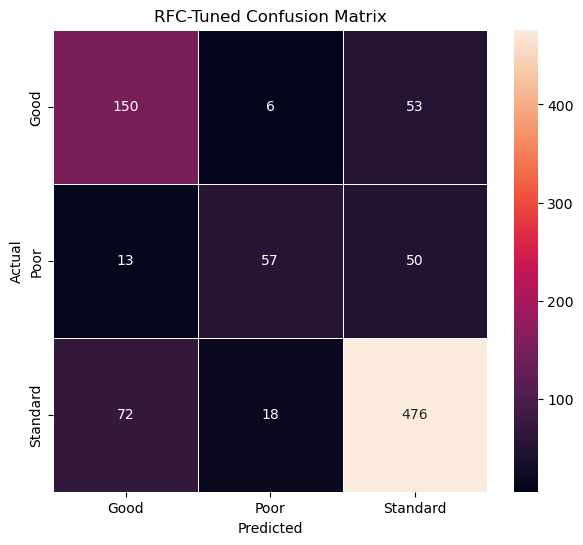


Classification Report
               precision    recall  f1-score   support

        Good       0.64      0.72      0.68       209
        Poor       0.70      0.47      0.57       120
    Standard       0.82      0.84      0.83       566

    accuracy                           0.76       895
   macro avg       0.72      0.68      0.69       895
weighted avg       0.76      0.76      0.76       895



In [ ]:
best_rfc = grid_search.best_estimator_
y_pred_grid = best_rfc.predict(X_test_clean)

accuracy = accuracy_score(y_test_clean, y_pred_grid)
print("RFC Accuracy:", accuracy)

matrix = confusion_matrix(y_test_clean, y_pred_grid)
plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix, 
    annot=True, 
    linewidth=0.5, 
    fmt="d",
    xticklabels=target_encoder.classes_, 
    yticklabels=target_encoder.classes_
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('RFC-Tuned Confusion Matrix')
plt.show()

print('\nClassification Report\n', classification_report(y_test_clean, y_pred_grid, target_names=target_encoder.classes_))